In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, explained_variance_score
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

In [3]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

numpy     : 1.26.4
keras     : 3.10.0
tensorflow: 2.19.0
seaborn   : 0.13.2
matplotlib: 3.9.2
sklearn   : 1.5.1
pandas    : 2.2.2
plotly    : 5.24.1



In [4]:
df = pd.read_csv("C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/Dados/commodities.csv")

In [5]:
df.shape

(124, 12)

In [6]:
df.head()

,data,petroleo_bruto,minerio_ferro,ouro,arroz,feijao,milho,soja,trigo,cafe,algodao,umidade
0,2012-12-01,323,455,3102.61,423.45,844.0,468.0,578.0,28.67,207.70504,117.7,79.261905
1,2013-01-01,345,546,3100.45,415.85,799.0,485.0,557.0,24.49,228.94287,4.5,82.193548
2,2013-02-01,362,595,3199.41,410.77,718.0,466.0,552.0,22.06,238.41747,25.1,74.839286
3,2013-03-01,376,636,3281.67,414.82,614.0,442.0,574.0,21.64,218.47599,53.6,77.935484
4,2013-04-01,383,738,3261.65,451.04,619.0,429.0,595.0,22.30,226.15010,166.0,80.450000


In [7]:
df.index = pd.to_datetime(df['data'], format = '%Y-%m-%d')

In [8]:
del df['data']

In [9]:
df.head()

,petroleo_bruto,minerio_ferro,ouro,arroz,feijao,milho,soja,trigo,cafe,algodao,umidade
data,,,,,,,,,,,
2012-12-01,323,455,3102.61,423.45,844.0,468.0,578.0,28.67,207.70504,117.7,79.261905
2013-01-01,345,546,3100.45,415.85,799.0,485.0,557.0,24.49,228.94287,4.5,82.193548
2013-02-01,362,595,3199.41,410.77,718.0,466.0,552.0,22.06,238.41747,25.1,74.839286
2013-03-01,376,636,3281.67,414.82,614.0,442.0,574.0,21.64,218.47599,53.6,77.935484
2013-04-01,383,738,3261.65,451.04,619.0,429.0,595.0,22.30,226.15010,166.0,80.450000


Text(0.5, 0, 'Data')

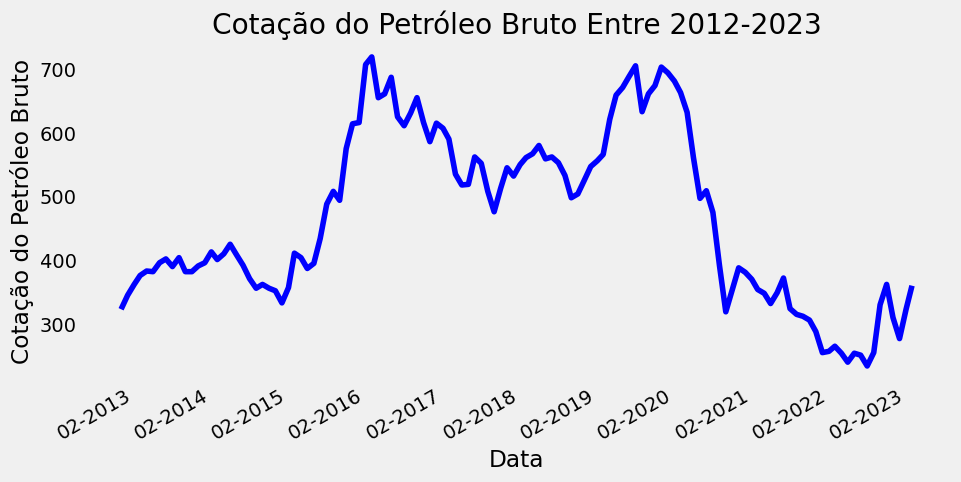

In [10]:
plt.figure(figsize = (10, 5))
plt.grid()
plt.plot(df.index, df['petroleo_bruto'], color = 'blue')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval = 12))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
plt.gcf().autofmt_xdate()
plt.title('Cotação do Petróleo Bruto Entre 2012-2023')
plt.ylabel('Cotação do Petróleo Bruto')
plt.xlabel('Data')

In [11]:
fig = make_subplots(rows = 10, cols =1)

fig.add_trace(go.Scatter(x = df.reset_index()['data'],
                         y = df.reset_index()['minerio_ferro'],
                         name = 'Minério de Ferro'), row = 1, col = 1
)

fig.add_trace(go.Scatter(x = df.reset_index()['data'],
                         y = df.reset_index()['ouro'],
                         name = 'Ouro'), row = 2, col = 1
)

fig.add_trace(go.Scatter(x = df.reset_index()['data'],
                         y = df.reset_index()['arroz'],
                         name = 'Arroz'), row = 3, col = 1
)

fig.add_trace(go.Scatter(x = df.reset_index()['data'],
                         y = df.reset_index()['feijao'],
                         name = 'feijao'), row = 4, col = 1
)

fig.add_trace(go.Scatter(x = df.reset_index()['data'],
                         y = df.reset_index()['milho'],
                         name = 'milho'), row = 5, col = 1
)

fig.add_trace(go.Scatter(x = df.reset_index()['data'],
                         y = df.reset_index()['soja'],
                         name = 'soja'), row = 6, col = 1
)

fig.add_trace(go.Scatter(x = df.reset_index()['data'],
                         y = df.reset_index()['trigo'],
                         name = 'trigo'), row = 7, col = 1
)

fig.add_trace(go.Scatter(x = df.reset_index()['data'],
                         y = df.reset_index()['cafe'],
                         name = 'cafe'), row = 8, col = 1
)

fig.add_trace(go.Scatter(x = df.reset_index()['data'],
                         y = df.reset_index()['umidade'],
                         name = 'umidade'), row = 9, col = 1
)

fig.update_layout(height = 1000, width = 1200, title_text = "Valores ao Longo do Tempo")
fig.show()

<Figure size 1000x600 with 0 Axes>

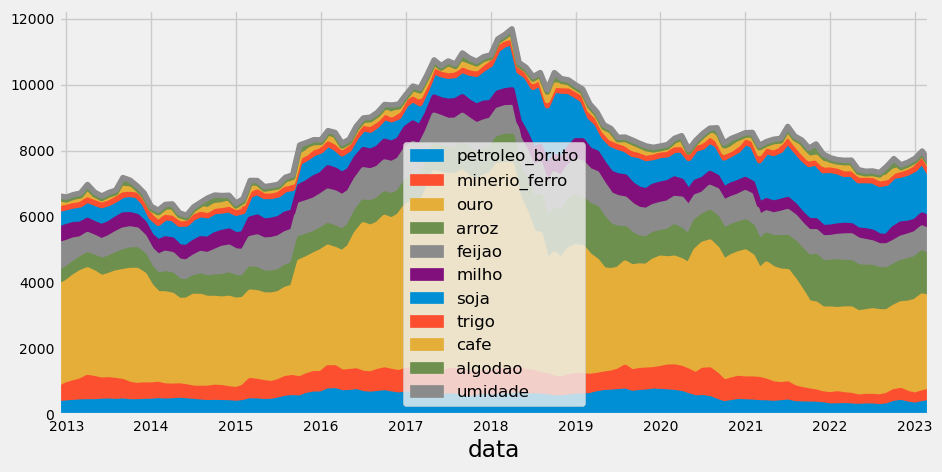

In [12]:
plt.figure(figsize = (10, 6))
ax = df.plot.area(fontsize = 10)
ax.set_xlabel('data');
ax.legend(fontsize=12);

In [13]:
train_size = int(len(df) * 0.8)
teste_size = len(df) - train_size

In [14]:
train = df.iloc[0:train_size]

In [15]:
test = df.iloc[train_size:len(df)]

In [16]:
print('Amostra de Treino:', len(train))
print('Amostra de Teste:', len(test))

Amostra de Treino: 99
Amostra de Teste: 25


In [17]:
variaveis_preditoras = ['minerio_ferro',
                        'ouro',
                        'arroz',
                        'feijao',
                        'milho',
                        'soja',
                        'trigo',
                        'cafe',
                        'algodao',
                        'umidade']

In [18]:
scaler_preditores = MinMaxScaler()

In [19]:
scaler_preditores = scaler_preditores.fit(train[variaveis_preditoras].to_numpy())

In [20]:
train.loc[:, variaveis_preditoras] = scaler_preditores.transform(train[variaveis_preditoras].to_numpy())

In [21]:
train.head()

,petroleo_bruto,minerio_ferro,ouro,arroz,feijao,milho,soja,trigo,cafe,algodao,umidade
data,,,,,,,,,,,
2012-12-01,323,0.112288,0.140918,0.010736,0.528090,0.253193,0.023302,0.109026,0.617026,0.366984,0.843364
2013-01-01,345,0.305085,0.140327,0.004301,0.443820,0.306536,0.009321,0.044200,0.815738,0.007619,0.983088
2013-02-01,362,0.408898,0.167408,0.000000,0.292135,0.246917,0.005992,0.006514,0.904388,0.073016,0.632580
2013-03-01,376,0.495763,0.189919,0.003429,0.097378,0.171609,0.020639,0.000000,0.717805,0.163492,0.780147
2013-04-01,383,0.711864,0.184440,0.034095,0.106742,0.130817,0.034621,0.010236,0.789608,0.520317,0.899990


In [22]:
test.loc[:, variaveis_preditoras] = scaler_preditores.transform(test[variaveis_preditoras].to_numpy())

In [23]:
test.head()

,petroleo_bruto,minerio_ferro,ouro,arroz,feijao,milho,soja,trigo,cafe,algodao,umidade
data,,,,,,,,,,,
2021-03-01,354,0.637712,0.194855,0.382454,0.381292,-0.039662,0.493342,0.455180,0.707023,0.548889,0.265874
2021-04-01,348,0.533898,0.264388,0.393951,0.213633,-0.054975,0.597870,0.515974,0.732180,0.017143,0.437683
2021-05-01,332,0.400424,0.246417,0.453802,0.235262,-0.092159,0.606525,0.530397,0.708895,0.444127,0.349664
2021-06-01,349,0.317797,0.234308,0.509834,0.320749,-0.074743,0.631824,0.593207,0.808476,0.181905,0.645800
2021-07-01,372,0.313559,0.223422,0.526454,0.426610,-0.066114,0.773462,0.641749,0.866202,0.436825,0.577974


In [24]:
scaler_target = MinMaxScaler()

In [25]:
scaler_target = scaler_target.fit(train[['petroleo_bruto']])

In [26]:
train['petroleo_bruto'] = scaler_target.transform(train[['petroleo_bruto']])

In [27]:
test['petroleo_bruto'] = scaler_target.transform(test[['petroleo_bruto']])

In [28]:
train.head()

,petroleo_bruto,minerio_ferro,ouro,arroz,feijao,milho,soja,trigo,cafe,algodao,umidade
data,,,,,,,,,,,
2012-12-01,0.0100,0.112288,0.140918,0.010736,0.528090,0.253193,0.023302,0.109026,0.617026,0.366984,0.843364
2013-01-01,0.0650,0.305085,0.140327,0.004301,0.443820,0.306536,0.009321,0.044200,0.815738,0.007619,0.983088
2013-02-01,0.1075,0.408898,0.167408,0.000000,0.292135,0.246917,0.005992,0.006514,0.904388,0.073016,0.632580
2013-03-01,0.1425,0.495763,0.189919,0.003429,0.097378,0.171609,0.020639,0.000000,0.717805,0.163492,0.780147
2013-04-01,0.1600,0.711864,0.184440,0.034095,0.106742,0.130817,0.034621,0.010236,0.789608,0.520317,0.899990


In [29]:
test.head()

,petroleo_bruto,minerio_ferro,ouro,arroz,feijao,milho,soja,trigo,cafe,algodao,umidade
data,,,,,,,,,,,
2021-03-01,0.0875,0.637712,0.194855,0.382454,0.381292,-0.039662,0.493342,0.455180,0.707023,0.548889,0.265874
2021-04-01,0.0725,0.533898,0.264388,0.393951,0.213633,-0.054975,0.597870,0.515974,0.732180,0.017143,0.437683
2021-05-01,0.0325,0.400424,0.246417,0.453802,0.235262,-0.092159,0.606525,0.530397,0.708895,0.444127,0.349664
2021-06-01,0.0750,0.317797,0.234308,0.509834,0.320749,-0.074743,0.631824,0.593207,0.808476,0.181905,0.645800
2021-07-01,0.1325,0.313559,0.223422,0.526454,0.426610,-0.066114,0.773462,0.641749,0.866202,0.436825,0.577974


In [30]:
def createDataset(X, y, time_steps):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        data = X.iloc[i:(i + time_steps)].values
        Xs.append(data)
        ys.append(y.iloc[i + time_steps])

    return np.array(Xs), np.array(ys)

In [31]:
time_steps = 3

In [32]:
X_train, y_train = createDataset(train, train.petroleo_bruto, time_steps)

In [33]:
X_test, y_test = createDataset(test, test.petroleo_bruto, time_steps)

In [34]:
print(X_test.shape, y_test.shape)

(22, 3, 11) (22,)


In [35]:
X_train_mlp = X_train[:, :, 0]

In [36]:
X_test_mlp = X_test[:, :, 0]

In [37]:
modelo_mlp = tf.keras.Sequential()
modelo_mlp.add(tf.keras.layers.Dense(128, input_dim = X_train.shape[1], activation = 'relu'))
modelo_mlp.add(tf.keras.layers.Dense(1))

In [38]:
modelo_mlp.compile(loss = 'mse', optimizer = 'adam')

In [39]:
modelo_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
%%time
modelo_mlp_history = modelo_mlp.fit(X_train_mlp,
                                            y_train,
                                            epochs = 100,
                                            batch_size = 32,
                                            validation_split = 0.1,
                                            shuffle = False)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - loss: 0.2820 - val_loss: 0.1191
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.2423 - val_loss: 0.0954
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.2062 - val_loss: 0.0745
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1734 - val_loss: 0.0568
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1439 - val_loss: 0.0420
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1175 - val_loss: 0.0301
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0945 - val_loss: 0.0213
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0746 - val_loss: 0.0154
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0578 - val_loss: 0.0123
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0441 - val_loss: 0.0117
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0333 - val_loss: 0.0135
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0251 - val_lo

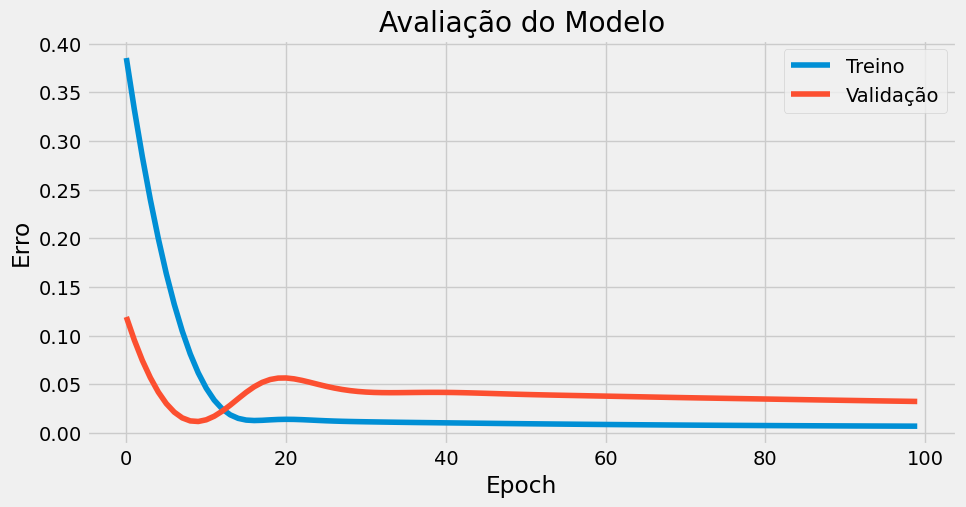

In [41]:
plt.plot(modelo_mlp_history.history['loss'])
plt.plot(modelo_mlp_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel('Erro')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [42]:
y_pred = modelo_mlp.predict(X_test_mlp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [43]:
y_pred

array([[0.11666697],
       [0.11560638],
       [0.14695096],
       [0.1274695 ],
       [0.08028869],
       [0.05369459],
       [0.04342634],
       [0.03078119],
       [0.0229148 ],
       [0.01253842],
       [0.01333901],
       [0.01764061],
       [0.01490988],
       [0.00915883],
       [0.01524507],
       [0.01560423],
       [0.00728638],
       [0.01093066],
       [0.06154966],
       [0.09886026],
       [0.03373626],
       [0.02919219]], dtype=float32)

In [44]:
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1))
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1))
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1, -1))

In [45]:
print(y_train_inv)

[[376. 383. 382. 396. 402. 390. 404. 382. 382. 391. 396. 413. 401. 410.
  425. 408. 392. 371. 356. 362. 356. 352. 333. 357. 411. 404. 387. 395.
  434. 488. 508. 494. 575. 614. 616. 707. 719. 655. 661. 687. 625. 611.
  631. 655. 616. 586. 615. 607. 590. 535. 518. 519. 562. 552. 508. 476.
  513. 545. 532. 550. 561. 567. 580. 559. 562. 553. 533. 498. 504. 525.
  547. 556. 566. 621. 659. 671. 688. 705. 633. 661. 674. 703. 694. 681.
  663. 632. 561. 497. 509. 475. 392. 319. 354. 388. 381. 370.]]


In [46]:
print(y_test_inv)

[[349. 372. 324. 315. 312. 306. 288. 255. 257. 265. 254. 240. 254. 251.
  234. 255. 330. 362. 310. 277. 323. 360.]]


In [47]:
print(y_pred_inv)

[[365.6668  365.24255 377.7804  369.9878  351.11548 340.47784 336.37054
  331.31247 328.16592 324.01538 324.3356  326.05624 324.96396 322.6635
  325.09802 325.2417  321.91455 323.37225 343.61987 358.5441  332.4945
  330.67688]]


In [48]:
y_train_inv = y_train_inv.flatten()
y_train_inv

array([376., 383., 382., 396., 402., 390., 404., 382., 382., 391., 396.,
       413., 401., 410., 425., 408., 392., 371., 356., 362., 356., 352.,
       333., 357., 411., 404., 387., 395., 434., 488., 508., 494., 575.,
       614., 616., 707., 719., 655., 661., 687., 625., 611., 631., 655.,
       616., 586., 615., 607., 590., 535., 518., 519., 562., 552., 508.,
       476., 513., 545., 532., 550., 561., 567., 580., 559., 562., 553.,
       533., 498., 504., 525., 547., 556., 566., 621., 659., 671., 688.,
       705., 633., 661., 674., 703., 694., 681., 663., 632., 561., 497.,
       509., 475., 392., 319., 354., 388., 381., 370.])

In [49]:
y_test_inv = y_test_inv.flatten()
y_test_inv

array([349., 372., 324., 315., 312., 306., 288., 255., 257., 265., 254.,
       240., 254., 251., 234., 255., 330., 362., 310., 277., 323., 360.])

In [50]:
y_pred_inv = y_pred_inv.flatten()
y_pred_inv

array([365.6668 , 365.24255, 377.7804 , 369.9878 , 351.11548, 340.47784,
       336.37054, 331.31247, 328.16592, 324.01538, 324.3356 , 326.05624,
       324.96396, 322.6635 , 325.09802, 325.2417 , 321.91455, 323.37225,
       343.61987, 358.5441 , 332.4945 , 330.67688], dtype=float32)

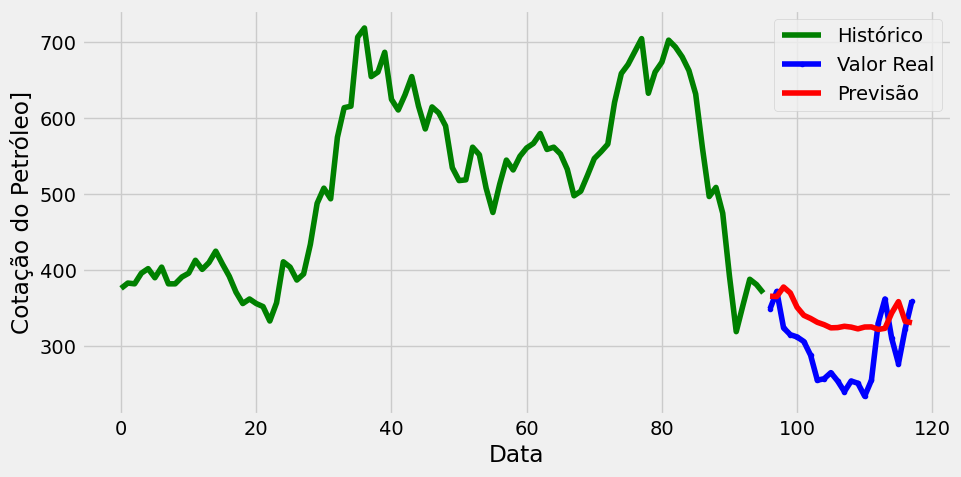

In [51]:
plt.plot(np.arange(0, len(y_train)),
         y_train_inv,
         color = 'green',
         label = "Histórico")

plt.plot(np.arange(len(y_train),
                   len(y_train) + len(y_test)),
         y_test_inv,
         color = 'blue',
         marker = '.',
         label = "Valor Real")

plt.plot(np.arange(len(y_train),
                   len(y_train) + len(y_test)),
         y_pred_inv,
         color = 'red',
         label = "Previsão")

plt.ylabel('Cotação do Petróleo]')
plt.xlabel('Data')
plt.legend()
plt.show();

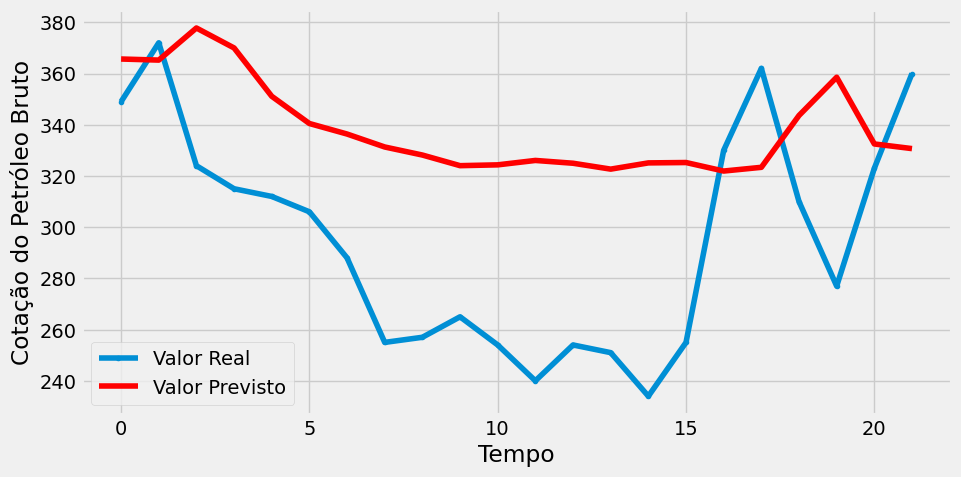

In [53]:
plt.plot(y_test_inv, marker = '.', label = 'Valor Real')
plt.plot(y_pred_inv, color = 'red', label = 'Valor Previsto')
plt.ylabel('Cotação do Petróleo Bruto')
plt.xlabel('Tempo')
plt.legend()
plt.show()

In [54]:
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [56]:
MDA_mlp = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_mlp)

MAE_mlp = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_mlp)

MSE_mlp = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_mlp)

RMSE_mlp = mean_squared_error(y_test_inv, y_pred_inv, squared = False)
print('RMSE:', RMSE_mlp)

EVS_mlp = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_mlp)

MDA: 0.38095238095238093
MAE: 50.986541748046875
MSE: 3259.68861254855
RMSE: 57.093682772689924
EVS Score: 0.23459457364131708
